In [6]:
import os
import sys
from decimal import Decimal
import warnings
import matplotlib.pyplot as plt
import pandas_ta as ta  # noqa: F401
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

root_path = os.path.abspath(os.path.join(os.getcwd(), '../'))
print(f"Root path: {root_path}")
sys.path.append(root_path)

from core.data_sources.clob import CLOBDataSource
from core.data_structures.candles import Candles
from dataHandler import load_candles_and_orderbook


Root path: /Users/schalkvisagie/csHonours/project/25349589-MN8-src/quants-lab


# Import data
- Get candles for the last x days

In [7]:

CONNECTOR_NAME = "binance"
INTERVALS = "1s"
TRADING_PAIR = "POL-USDT"

GMM_LOOKBACK = 900

start_time = 1749899778-GMM_LOOKBACK-1
# end_time = 1748699400
# start_time_of_orderbook = 1749899778
end_time_of_orderbook = 1750080486
end_time = end_time_of_orderbook

candles_and_ob_df = load_candles_and_orderbook(
    CONNECTOR_NAME, 
    INTERVALS, 
    TRADING_PAIR,
    start_time=start_time,
    end_time=end_time
)
candles_and_ob_df

Filtered candles to time range: 1749898877 to 1750080486
Candles data shape after filtering: (181610, 10)


2025-06-25 10:51:19,606 - asyncio - ERROR - Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x16a5e53d0>


Filtered orderbook to time range: 1749898877 to 1750080486
Orderbook data shape after filtering: (180754, 3)
Final merged data shape: (181661, 14)
=== DATA INTEGRITY CHECK ===
Total rows: 181661
Time range: 1749898877 to 1750080486
Expected time span: 181610 seconds

--- TIMESTAMP INTEGRITY ---
Missing timestamps: 0
Duplicate timestamps: 51

--- ORDERBOOK DATA INTEGRITY ---
Missing bids: 901
Missing asks: 901

--- CANDLE DATA INTEGRITY ---
Missing open: 0
Missing high: 0
Missing low: 0
Missing close: 0
Missing volume: 0

--- SUMMARY ---
❌ Timestamp integrity: 0 missing, 51 duplicates
❌ Orderbook integrity: 901 missing bids, 901 missing asks


,timestamp,open,high,low,close,volume,quote_asset_volume,n_trades,taker_buy_base_volume,taker_buy_quote_volume,bids,asks,datetime,taker_sell_base_volume
0,1749898877,0.2025,0.2025,0.2025,0.2025,0,0,0,0,0,NaN,NaN,2025-06-14 11:01:17,0
1,1749898878,0.2025,0.2025,0.2025,0.2025,37.6,7.614,1,0,0,NaN,NaN,2025-06-14 11:01:18,37.6
2,1749898879,0.2025,0.2025,0.2025,0.2025,0,0,0,0,0,NaN,NaN,2025-06-14 11:01:19,0
3,1749898880,0.2025,0.2025,0.2025,0.2025,0,0,0,0,0,NaN,NaN,2025-06-14 11:01:20,0
4,1749898881,0.2025,0.2026,0.2025,0.2026,612.6,124.05946,3,79.6,16.12696,NaN,NaN,2025-06-14 11:01:21,533
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181656,1750080482,0.2031,0.2031,0.2031,0.2031,0,0,0,0,0,"[[0.2031, 370.8], [0.203, 22341.8], [0.2029, 4...","[[0.20320000000000002, 32681.5], [0.2033, 9478...",2025-06-16 13:28:02,0
181657,1750080483,0.2031,0.2031,0.2031,0.2031,370.8,75.30948,2,0,0,"[[0.2031, 370.8], [0.203, 24741.8], [0.2029, 4...","[[0.20320000000000002, 30681.5], [0.2033, 9678...",2025-06-16 13:28:03,370.8
181658,1750080484,0.2031,0.2031,0.2031,0.2031,0,0,0,0,0,"[[0.203, 13001.0], [0.2029, 27351.0], [0.2028,...","[[0.2031, 20544.6], [0.20320000000000002, 5789...",2025-06-16 13:28:04,0
181659,1750080485,0.2031,0.2031,0.2031,0.2031,0,0,0,0,0,"[[0.203, 16001.0], [0.2029, 26025.7], [0.2028,...","[[0.2031, 7975.3], [0.20320000000000002, 57892...",2025-06-16 13:28:05,0


In [8]:
# candles_and_ob_df.to_excel('candles_and_ob_data.xlsx', index=False)

# Feature generation
#### Log returns:

In [20]:
features_df = candles_and_ob_df.copy()

print(f"Original data shape: {features_df.shape}")
print(f"Date range: {pd.to_datetime(features_df['timestamp'].min(), unit='s')} to {pd.to_datetime(features_df['timestamp'].max(), unit='s')}")

# 1. LOG RETURNS - log(P_t / P_{t-1})
print("\n--- Computing Log Returns ---")
features_df['log_returns'] = np.log(features_df['close'] / features_df['close'].shift(1))

# Handle edge cases for log returns
initial_nans = features_df['log_returns'].isna().sum()
zero_prices = (features_df['close'] == 0).sum()
print(f"Initial NaNs in log_returns: {initial_nans}")
print(f"Zero prices detected: {zero_prices}")

# Replace inf and -inf with 0 (if any price jumps cause issues)
features_df['log_returns'] = features_df['log_returns'].replace([np.inf, -np.inf], 0)
features_df['log_returns'] = features_df['log_returns'].fillna(0)
# features_df


Original data shape: (181661, 14)
Date range: 2025-06-14 11:01:17 to 2025-06-16 13:28:06

--- Computing Log Returns ---
Initial NaNs in log_returns: 1
Zero prices detected: 0


In [23]:

# 2. VOLUME - Total trading volume from OHLCV
print("\n--- Processing Volume ---")
features_df['volume_feature'] = features_df['volume'].copy()
zero_volume_count = (features_df['volume_feature'] == 0).sum()
print(f"Zero volume periods: {zero_volume_count/features_df.shape[0]:.2%} of total data")
features_df



--- Processing Volume ---
Zero volume periods: 88.93% of total data


,timestamp,open,high,low,close,volume,quote_asset_volume,n_trades,taker_buy_base_volume,taker_buy_quote_volume,bids,asks,datetime,taker_sell_base_volume,log_returns,volume_feature
0,1749898877,0.2025,0.2025,0.2025,0.2025,0,0,0,0,0,NaN,NaN,2025-06-14 11:01:17,0,0,0
1,1749898878,0.2025,0.2025,0.2025,0.2025,37.6,7.614,1,0,0,NaN,NaN,2025-06-14 11:01:18,37.6,0,37.6
2,1749898879,0.2025,0.2025,0.2025,0.2025,0,0,0,0,0,NaN,NaN,2025-06-14 11:01:19,0,0,0
3,1749898880,0.2025,0.2025,0.2025,0.2025,0,0,0,0,0,NaN,NaN,2025-06-14 11:01:20,0,0,0
4,1749898881,0.2025,0.2026,0.2025,0.2026,612.6,124.05946,3,79.6,16.12696,NaN,NaN,2025-06-14 11:01:21,533,0.00049371,612.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181656,1750080482,0.2031,0.2031,0.2031,0.2031,0,0,0,0,0,"[[0.2031, 370.8], [0.203, 22341.8], [0.2029, 4...","[[0.20320000000000002, 32681.5], [0.2033, 9478...",2025-06-16 13:28:02,0,0,0
181657,1750080483,0.2031,0.2031,0.2031,0.2031,370.8,75.30948,2,0,0,"[[0.2031, 370.8], [0.203, 24741.8], [0.2029, 4...","[[0.20320000000000002, 30681.5], [0.2033, 9678...",2025-06-16 13:28:03,370.8,0,370.8
181658,1750080484,0.2031,0.2031,0.2031,0.2031,0,0,0,0,0,"[[0.203, 13001.0], [0.2029, 27351.0], [0.2028,...","[[0.2031, 20544.6], [0.20320000000000002, 5789...",2025-06-16 13:28:04,0,0,0
181659,1750080485,0.2031,0.2031,0.2031,0.2031,0,0,0,0,0,"[[0.203, 16001.0], [0.2029, 26025.7], [0.2028,...","[[0.2031, 7975.3], [0.20320000000000002, 57892...",2025-06-16 13:28:05,0,0,0


In [27]:

# 3. TAKER RATIO - taker_buy_volume / total_taker_volume
print("\n--- Computing Taker Ratio ---")

# Calculate total taker volume
total_taker_volume = features_df['taker_buy_base_volume'] + features_df['taker_sell_base_volume']

# Calculate taker ratio with safe division
features_df['taker_ratio'] = np.where(
    total_taker_volume > 0,
    features_df['taker_buy_base_volume'] / total_taker_volume,
    0.5  # Default to neutral ratio when no taker volume
)

print("Using taker buy/sell volumes for taker_ratio")
features_df.head()



--- Computing Taker Ratio ---
Using taker buy/sell volumes for taker_ratio


,timestamp,open,high,low,close,volume,quote_asset_volume,n_trades,taker_buy_base_volume,taker_buy_quote_volume,bids,asks,datetime,taker_sell_base_volume,log_returns,volume_feature,taker_ratio
0,1749898877,0.2025,0.2025,0.2025,0.2025,0,0,0,0,0,NaN,NaN,2025-06-14 11:01:17,0,0,0,0.5
1,1749898878,0.2025,0.2025,0.2025,0.2025,37.6,7.614,1,0,0,NaN,NaN,2025-06-14 11:01:18,37.6,0,37.6,0
2,1749898879,0.2025,0.2025,0.2025,0.2025,0,0,0,0,0,NaN,NaN,2025-06-14 11:01:19,0,0,0,0.5
3,1749898880,0.2025,0.2025,0.2025,0.2025,0,0,0,0,0,NaN,NaN,2025-06-14 11:01:20,0,0,0,0.5
4,1749898881,0.2025,0.2026,0.2025,0.2026,612.6,124.05946,3,79.6,16.12696,NaN,NaN,2025-06-14 11:01:21,533,0.00049371,612.6,0.12993797


In [32]:
# 4. CREATE FINAL FEATURES DATAFRAME
print("\n--- Creating Final Features DataFrame ---")

# Select only the required feature columns
feature_columns = ['timestamp', 'datetime', 'log_returns', 'volume_feature', 'taker_ratio']
available_columns = [col for col in feature_columns if col in features_df.columns]

gmm_features_df = features_df[available_columns].copy()

# Rename volume column for clarity
if 'volume_feature' in gmm_features_df.columns:
    gmm_features_df.rename(columns={'volume_feature': 'volume'}, inplace=True)

# 5. DATA QUALITY CHECKS
print("\n--- Data Quality Checks ---")

# Check for NaNs
nan_counts = gmm_features_df[['log_returns', 'volume', 'taker_ratio']].isna().sum()
print("NaN counts per feature:")
for feature, count in nan_counts.items():
    print(f"  {feature}: {count}")

# Check for any NaNs and warn
total_nans = nan_counts.sum()
if total_nans > 0:
    print(f"\n⚠️  WARNING: Found {total_nans} total NaN values in the feature columns!")
    print("You may want to handle these NaNs before proceeding with GMM-HMM modeling.")
    
    # Show which rows have NaNs
    nan_rows = gmm_features_df[['log_returns', 'volume', 'taker_ratio']].isna().any(axis=1)
    nan_row_indices = gmm_features_df[nan_rows].index.tolist()
    if len(nan_row_indices) <= 10:
        print(f"Rows with NaNs: {nan_row_indices}")
    else:
        print(f"First 10 rows with NaNs: {nan_row_indices[:10]}")
        print(f"... and {len(nan_row_indices) - 10} more rows")
else:
    print("✓ No NaN values found in feature columns")

print(f"\nFinal feature DataFrame shape: {gmm_features_df.shape}")
gmm_features_df


--- Creating Final Features DataFrame ---

--- Data Quality Checks ---
NaN counts per feature:
  log_returns: 0
  volume: 0
  taker_ratio: 0
✓ No NaN values found in feature columns

Final feature DataFrame shape: (181661, 5)


,timestamp,datetime,log_returns,volume,taker_ratio
0,1749898877,2025-06-14 11:01:17,0,0,0.5
1,1749898878,2025-06-14 11:01:18,0,37.6,0
2,1749898879,2025-06-14 11:01:19,0,0,0.5
3,1749898880,2025-06-14 11:01:20,0,0,0.5
4,1749898881,2025-06-14 11:01:21,0.00049371,612.6,0.12993797
...,...,...,...,...,...
181656,1750080482,2025-06-16 13:28:02,0,0,0.5
181657,1750080483,2025-06-16 13:28:03,0,370.8,0
181658,1750080484,2025-06-16 13:28:04,0,0,0.5
181659,1750080485,2025-06-16 13:28:05,0,0,0.5


In [33]:

# 6. FEATURE STATISTICS
print("\n--- Feature Statistics ---")
feature_stats = gmm_features_df[['log_returns', 'volume', 'taker_ratio']].describe()
print(feature_stats)

# Check for infinite values
inf_counts = np.isinf(gmm_features_df[['log_returns', 'volume', 'taker_ratio']]).sum()
print(f"\nInfinite values per feature:")
for feature, count in inf_counts.items():
    print(f"  {feature}: {count}")



--- Feature Statistics ---
       log_returns        volume  taker_ratio
count       181661        181661       181661
mean    0.00000002  261.88398941   0.49696774
std     0.00012785 3777.32216713   0.16407975
min    -0.00297767             0            0
25%              0             0          0.5
50%              0             0          0.5
75%              0             0          0.5
max     0.00201309      648102.1            1

Infinite values per feature:
  log_returns: 0
  volume: 0
  taker_ratio: 0


## Feature smooting and noise reduction

Smoothed log rets, volume and taker ratio with an 60 sec ema


=== STEP 3: FEATURE SMOOTHING ===
EMA parameters: span=60 seconds, alpha=0.033
Computing EMA smoothed features...
✓ EMA features computed successfully

=== EMA VERIFICATION ===
✓ No NaNs in EMA features: True (count: 0)
✓ EMA window size: 60 seconds (consistent across all features)

=== VOLATILITY REDUCTION ANALYSIS ===
✓ log_returns: Raw std=0.000128, EMA std=0.000014, Reduction=89.4%
✓ volume: Raw std=3777.322167, EMA std=578.068810, Reduction=84.7%
✓ taker_ratio: Raw std=0.164080, EMA std=0.025837, Reduction=84.3%

=== SMOOTHING VISUALIZATION ===


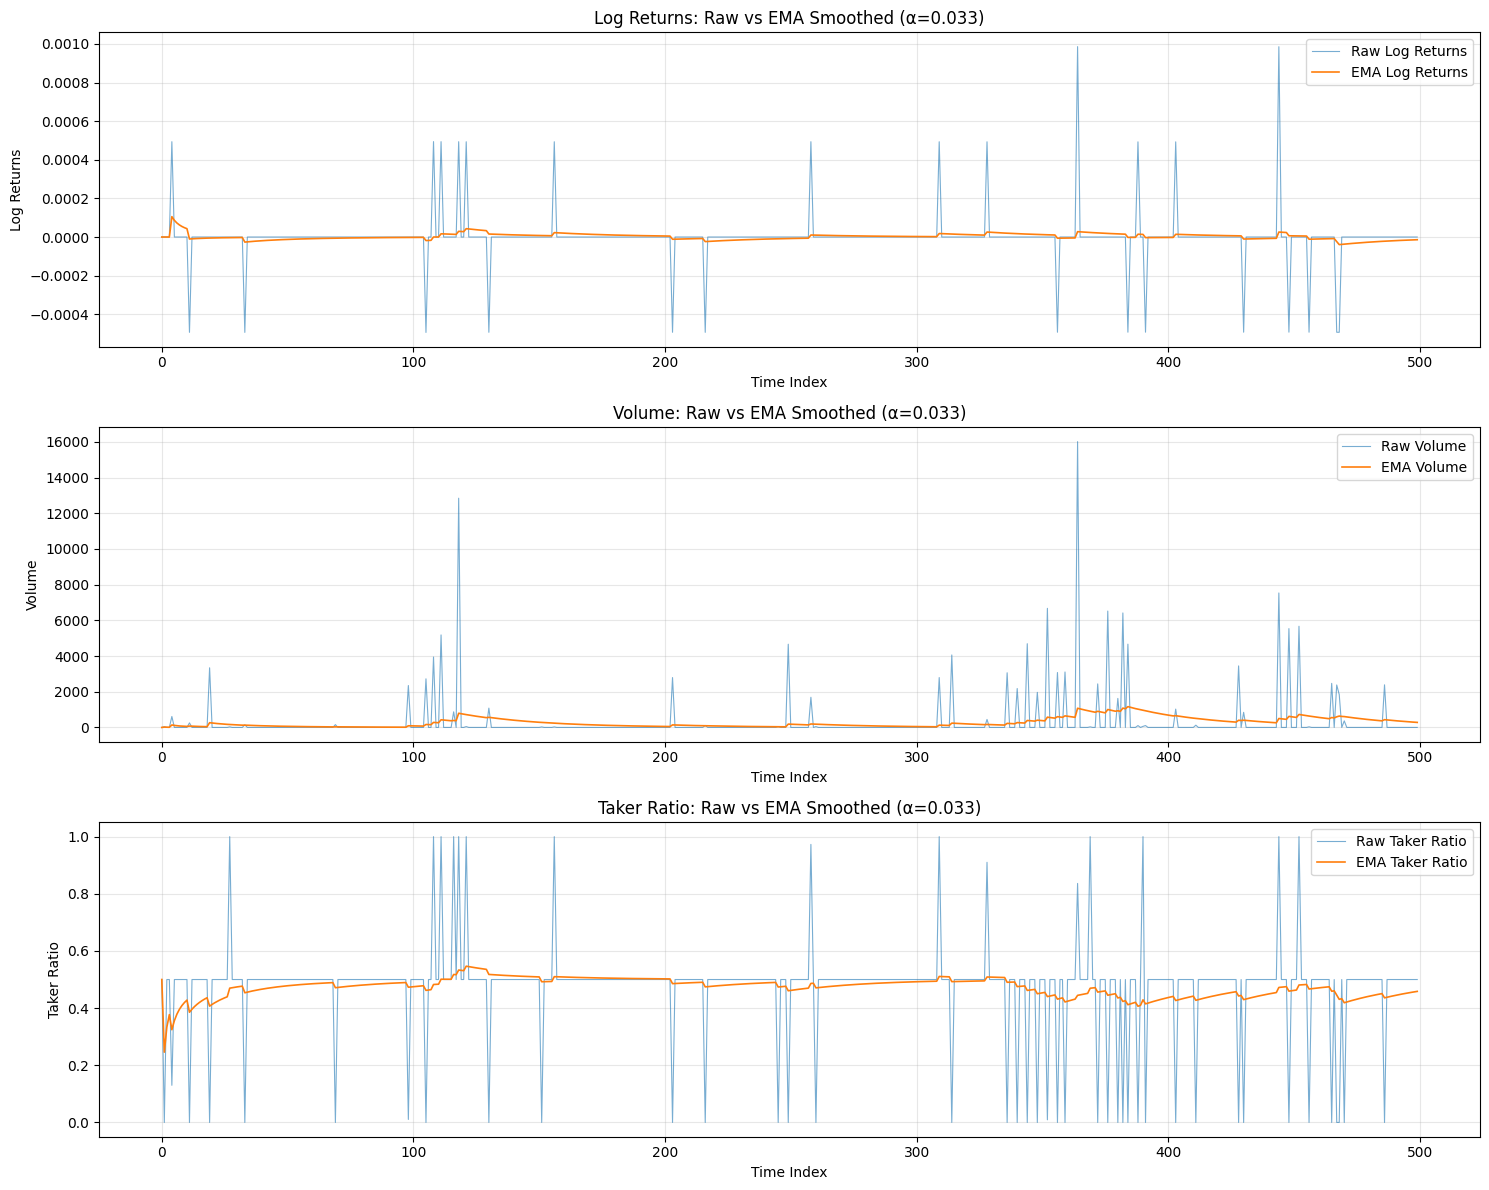

✓ Smoothed features show reduced volatility compared to raw features
✓ EMA implementation complete - ready for GMM-HMM training!

=== FINAL FEATURE SUMMARY ===
Total features available: 11
Raw features: log_returns, volume, taker_ratio
Smoothed features: log_returns_ema, volume_ema, taker_ratio_ema
Data points: 181661
Feature DataFrame shape: (181661, 11)


In [39]:
# 8. STEP 3: FEATURE SMOOTHING TO REDUCE NOISE
print("\n=== STEP 3: FEATURE SMOOTHING ===")

# EMA parameters
ema_span = 60  # 120 seconds window
alpha = 2 / (ema_span + 1)  # alpha = 2/(n+1) formula
print(f"EMA parameters: span={ema_span} seconds, alpha={alpha:.3f}")

# Apply EMA smoothing to all features
print("Computing EMA smoothed features...")

# Compute EMA for each feature
gmm_features_df['log_returns_ema'] = gmm_features_df['log_returns'].ewm(span=ema_span, adjust=True).mean()
gmm_features_df['volume_ema'] = gmm_features_df['volume'].ewm(span=ema_span, adjust=True).mean()
gmm_features_df['taker_ratio_ema'] = gmm_features_df['taker_ratio'].ewm(span=ema_span, adjust=True).mean()

# Handle initial NaNs by filling with raw values (first few observations)
gmm_features_df['log_returns_ema'] = gmm_features_df['log_returns_ema'].fillna(gmm_features_df['log_returns'])
gmm_features_df['volume_ema'] = gmm_features_df['volume_ema'].fillna(gmm_features_df['volume'])
gmm_features_df['taker_ratio_ema'] = gmm_features_df['taker_ratio_ema'].fillna(gmm_features_df['taker_ratio'])

print("✓ EMA features computed successfully")

# Verification of EMA features
print("\n=== EMA VERIFICATION ===")

# Check for NaNs in EMA features
ema_features = ['log_returns_ema', 'volume_ema', 'taker_ratio_ema']
ema_nans = gmm_features_df[ema_features].isna().sum().sum()
print(f"✓ No NaNs in EMA features: {ema_nans == 0} (count: {ema_nans})")

# Verify EMA window consistency
print(f"✓ EMA window size: {ema_span} seconds (consistent across all features)")

# Calculate volatility reduction (standard deviation comparison)
print("\n=== VOLATILITY REDUCTION ANALYSIS ===")
for feature in ['log_returns', 'volume', 'taker_ratio']:
    raw_std = gmm_features_df[feature].std()
    ema_std = gmm_features_df[f'{feature}_ema'].std()
    reduction = (raw_std - ema_std) / raw_std * 100
    print(f"✓ {feature}: Raw std={raw_std:.6f}, EMA std={ema_std:.6f}, Reduction={reduction:.1f}%")

# Display sample of smoothed features
# print(f"\nSample of smoothed features:")
# display_cols = ['timestamp', 'log_returns', 'log_returns_ema', 'volume', 'volume_ema', 'taker_ratio', 'taker_ratio_ema']
# print(gmm_features_df[display_cols].head(15))

# Visualization of smoothing effect
print("\n=== SMOOTHING VISUALIZATION ===")
import matplotlib.pyplot as plt

# Create subplots for visualization
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
sample_range = slice(0, 500)  # First 500 data points for clear visualization

features_to_plot = [
    ('log_returns', 'log_returns_ema', 'Log Returns'),
    ('volume', 'volume_ema', 'Volume'),
    ('taker_ratio', 'taker_ratio_ema', 'Taker Ratio')
]

for i, (raw_col, ema_col, title) in enumerate(features_to_plot):
    axes[i].plot(gmm_features_df.index[sample_range], 
                 gmm_features_df[raw_col].iloc[sample_range], 
                 alpha=0.6, label=f'Raw {title}', linewidth=0.8)
    axes[i].plot(gmm_features_df.index[sample_range], 
                 gmm_features_df[ema_col].iloc[sample_range], 
                 label=f'EMA {title}', linewidth=1.2)
    axes[i].set_title(f'{title}: Raw vs EMA Smoothed (α={alpha:.3f})')
    axes[i].set_xlabel('Time Index')
    axes[i].set_ylabel(title)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Smoothed features show reduced volatility compared to raw features")
print("✓ EMA implementation complete - ready for GMM-HMM training!")

# Final summary
print(f"\n=== FINAL FEATURE SUMMARY ===")
print(f"Total features available: {len(gmm_features_df.columns)}")
print(f"Raw features: log_returns, volume, taker_ratio")
print(f"Smoothed features: log_returns_ema, volume_ema, taker_ratio_ema")
print(f"Data points: {len(gmm_features_df)}")
print(f"Feature DataFrame shape: {gmm_features_df.shape}")

In [40]:
print("✓ EMA implementation complete - ready for GMM-HMM training!")

# 9. STEP 4: FEATURE STANDARDIZATION
print("\n=== STEP 4: FEATURE STANDARDIZATION ===")

# Standardization parameters
window_size = 900  # 15-minute windows (900 seconds)
outlier_cap = 5000    # Cap standardized values at ±5000
print(f"Standardization parameters: window_size={window_size} seconds (15 min), outlier_cap=±{outlier_cap}")

# Apply rolling window standardization to EMA features
print("Computing rolling window standardized features...")

ema_features = ['log_returns_ema', 'volume_ema', 'taker_ratio_ema']
standardized_features = []

for feature in ema_features:
    print(f"  Standardizing {feature}...")
    
    # Compute rolling mean and std
    rolling_mean = gmm_features_df[feature].rolling(window=window_size, min_periods=1).mean()
    rolling_std = gmm_features_df[feature].rolling(window=window_size, min_periods=1).std()
    
    # Handle cases where std is 0 (constant values in window)
    rolling_std = rolling_std.replace(0, 1e-8)  # Avoid division by zero
    
    # Compute z-scores
    z_scores = (gmm_features_df[feature] - rolling_mean) / rolling_std
    
    # Cap outliers at ±5
    z_scores_capped = z_scores.clip(lower=-outlier_cap, upper=outlier_cap)
    
    # Store standardized feature
    standardized_col = f'{feature}_std'
    gmm_features_df[standardized_col] = z_scores_capped
    standardized_features.append(standardized_col)
    
    print(f"    ✓ {standardized_col} computed")

print("✓ All EMA features standardized successfully")

# # Verification of standardized features
# print("\n=== STANDARDIZATION VERIFICATION ===")

# # Check for NaNs in standardized features
# std_nans = gmm_features_df[standardized_features].isna().sum().sum()
# print(f"✓ No NaNs in standardized features: {std_nans == 0} (count: {std_nans})")

# # Verify window size consistency
# print(f"✓ Standardization window size: {window_size} seconds (consistent across all features)")

# # Check mean and std within sample windows
# print("\n=== ROLLING WINDOW STATISTICS VERIFICATION ===")
# sample_windows = [
#     (0, window_size),           # First window
#     (window_size, 2*window_size), # Second window
#     (-window_size, None)        # Last window
# ]

# for i, (start, end) in enumerate(sample_windows):
#     if end is None:
#         window_data = gmm_features_df.iloc[start:]
#         window_name = f"Window {i+1} (last {window_size} points)"
#     else:
#         window_data = gmm_features_df.iloc[start:end]
#         window_name = f"Window {i+1} (points {start}-{end-1})"
    
#     if len(window_data) > 0:
#         print(f"\n{window_name}:")
#         for feature in standardized_features:
#             mean_val = window_data[feature].mean()
#             std_val = window_data[feature].std()
#             print(f"  {feature}: mean={mean_val:.6f}, std={std_val:.6f}")

# # Check for outlier capping effectiveness
# print("\n=== OUTLIER CAPPING VERIFICATION ===")
# for feature in standardized_features:
#     min_val = gmm_features_df[feature].min()
#     max_val = gmm_features_df[feature].max()
#     outliers_capped = ((gmm_features_df[feature] == -outlier_cap) | 
#                       (gmm_features_df[feature] == outlier_cap)).sum()
#     print(f"✓ {feature}: range=[{min_val:.3f}, {max_val:.3f}], capped_outliers={outliers_capped}")

# # Display sample of standardized features
# print(f"\nSample of standardized features:")
# display_cols = ['timestamp'] + [f for f in ema_features] + standardized_features
# print(gmm_features_df[display_cols].head(15))

# # Statistical summary of standardized features
# print(f"\n=== STANDARDIZED FEATURES SUMMARY ===")
# print(gmm_features_df[standardized_features].describe())

# # Verify no extreme outliers beyond caps
# extreme_outliers = 0
# for feature in standardized_features:
#     extreme_count = ((gmm_features_df[feature] < -outlier_cap) | 
#                     (gmm_features_df[feature] > outlier_cap)).sum()
#     extreme_outliers += extreme_count

# print(f"✓ No extreme outliers beyond ±{outlier_cap}: {extreme_outliers == 0} (count: {extreme_outliers})")

# # Final summary
# print(f"\n=== FEATURE STANDARDIZATION COMPLETE ===")
# print(f"Standardized features: {standardized_features}")
# print(f"Window-based standardization: {window_size} seconds (15 minutes)")
# print(f"Outlier capping: ±{outlier_cap}")
# print(f"Ready for GMM-HMM model training with robust, standardized features!")

# # Optional: Show distribution of standardized features
# print(f"\n=== DISTRIBUTION CHECK ===")
# for feature in standardized_features:
#     feature_data = gmm_features_df[feature]
#     print(f"{feature}: mean={feature_data.mean():.6f}, std={feature_data.std():.6f}, "
#           f"min={feature_data.min():.3f}, max={feature_data.max():.3f}")

✓ EMA implementation complete - ready for GMM-HMM training!

=== STEP 4: FEATURE STANDARDIZATION ===
Standardization parameters: window_size=900 seconds (15 min), outlier_cap=±5000
Computing rolling window standardized features...
  Standardizing log_returns_ema...
    ✓ log_returns_ema_std computed
  Standardizing volume_ema...
    ✓ volume_ema_std computed
  Standardizing taker_ratio_ema...
    ✓ taker_ratio_ema_std computed
✓ All EMA features standardized successfully


In [45]:
gmm_features_df.head()

,timestamp,datetime,log_returns,volume,taker_ratio,log_returns_ema,volume_ema,taker_ratio_ema,log_returns_ema_std,volume_ema_std,taker_ratio_ema_std
0,1749898877,2025-06-14 11:01:17,0,0,0.5,0,0,0.5,NaN,NaN,NaN
1,1749898878,2025-06-14 11:01:18,0,37.6,0,0,19.11333333,0.24583333,0,0.70710678,-0.70710678
2,1749898879,2025-06-14 11:01:19,0,0,0.5,0,12.52869179,0.33339506,0,0.20406326,-0.20406326
3,1749898880,2025-06-14 11:01:20,0,0,0.5,0,9.23819957,0.3771516,0,-0.12343035,0.12343035
4,1749898881,2025-06-14 11:01:21,0.00049371,612.6,0.12993797,0.00010543,138.0871635,0.3243587,1.78885438,1.77601291,-0.34065704


In [46]:
gmm_features_df['volume_ema_std'].describe()

count        181660
mean     0.03702899
std      1.26961185
min     -1.85350279
25%     -0.57215517
50%     -0.33913627
75%      0.15565782
max      29.3216242
Name: volume_ema_std, dtype: float64

In [17]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Slice the last 50,000 entries
n_entries = 50000
candles_subset = candles_df.tail(n_entries)
regime_probs_subset = regime_probs[-n_entries:] if isinstance(regime_probs, np.ndarray) else regime_probs.tail(n_entries)

# Create figure with secondary y-axis
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.03, 
    subplot_titles=(f'{trading_pair} (Last {n_entries:,} entries)', 'Regime Probabilities'),
    row_heights=[0.7, 0.3]
)

# Add candlestick
fig.add_trace(go.Candlestick(x=candles_subset.index,
                             open=candles_subset['open'],
                             high=candles_subset['high'],
                             low=candles_subset['low'],
                             close=candles_subset['close'],
                             name='OHLC'),
              row=1, col=1)

regime_colors = ['#FF5733', '#33FF57', '#3357FF', '#F3FF33']  # Choose your colors
for i in range(4):
    fig.add_trace(
        go.Scatter(
            x=candles_subset.index,
            y=regime_probs_subset[:, i] if isinstance(regime_probs_subset, np.ndarray) else regime_probs_subset.iloc[:, i],
            mode='lines',
            name=f'Regime {i}',
            line=dict(color=regime_colors[i], width=2)
        ),
        row=2, col=1
    )

# Update layout for dark theme
fig.update_layout(
    title=f'{CONNECTOR_NAME} - {trading_pair} - {INTERVALS} (Last {n_entries:,} entries)',
    width=1200, height=800,
    font=dict(color='#e1e1e1'),
    plot_bgcolor='#1e1e1e',
    paper_bgcolor='#1e1e1e',
    xaxis_rangeslider_visible=False,
    legend=dict(bgcolor='rgba(0,0,0,0)'),
    yaxis=dict(title='Price'),
    yaxis2=dict(title='Regime Probability', showgrid=False),
    showlegend=True
)

# Update axes
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#323232', zeroline=False)

# Show the plot
fig.show()

2025-06-25 10:51:23,469 - asyncio - ERROR - Task was destroyed but it is pending!
task: <Task pending name='Task-156' coro=<safe_wrapper() running at /opt/homebrew/anaconda3/envs/quants-lab/lib/python3.12/site-packages/hummingbot/core/utils/async_utils.py:9> wait_for=<Future pending cb=[Task.task_wakeup()]>>


NameError: name 'candles_df' is not defined

In [ ]:
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots

# # Create figure with secondary y-axis
# fig = make_subplots(
#     rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.03, 
#     subplot_titles=(trading_pair, 'Regime Probabilities'),
#     row_heights=[0.7, 0.3]
# )

# # Add candlestick
# fig.add_trace(go.Candlestick(x=candles_df.index,
#                              open=candles_df['open'],
#                              high=candles_df['high'],
#                              low=candles_df['low'],
#                              close=candles_df['close'],
#                              name='OHLC'),
#               row=1, col=1)


# regime_colors = ['#FF5733', '#33FF57', '#3357FF', '#F3FF33']  # Choose your colors
# for i in range(4):
#     fig.add_trace(
#         go.Scatter(
#             x=candles_df.index,
#             y=regime_probs[:, i] if isinstance(regime_probs, np.ndarray) else regime_probs.iloc[:, i],
#             mode='lines',
#             name=f'Regime {i}',
#             line=dict(color=regime_colors[i], width=2)
#         ),
#         row=2, col=1
#     )


# # Update layout for dark theme
# fig.update_layout(
#     title=f'{CONNECTOR_NAME} - {trading_pair} - {INTERVALS}',
#     width=1200, height=800,
#     font=dict(color='#e1e1e1'),
#     plot_bgcolor='#1e1e1e',
#     paper_bgcolor='#1e1e1e',
#     xaxis_rangeslider_visible=False,
#     legend=dict(bgcolor='rgba(0,0,0,0)'),
#     yaxis=dict(title='Price'),
#     yaxis2=dict(title='Regime Probability', showgrid=False),
#     showlegend=True
# )

# # Update axes
# fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#323232', zeroline=False)
# # fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#323232', zeroline=False)

# # Show the plot
# fig.show()

### Signal Generation
The `signal` column is generated by evaluating the regime probabilities for each time step. 
For each row, if the highest regime probability exceeds a threshold, the signal is set to the regime number (0–3) with the highest probability. If no regime probability exceeds the threshold, the signal is set to -1, indicating no strong regime detected. 

This approach helps identify periods where the model is confident about a particular regime.

In [ ]:
# Generate signal
threshold = 0.65
candles_df["signal"] = 0

# Find the regime with the highest probability above the threshold
regime_prob_cols = [f'regime_prob_{i}' for i in range(regime_probs.shape[1])]
probs = candles_df[regime_prob_cols]

# For each row, get the regime with the highest probability above threshold, else -1
candles_df["signal"] = probs.apply(
    lambda row: int(row.idxmax()[-1]) if row.max() > threshold else -1, axis=1
)

# candles_df[5000:]

In [ ]:
# from plotly.subplots import make_subplots
# import plotly.graph_objects as go

# fig = make_subplots(
#     rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.02,
#     subplot_titles=('OHLC', 'Regime Probabilities', 'Signal'),
#     row_heights=[0.6, 0.2, 0.2]
# )

# # Add candlestick plot
# fig.add_trace(
#     go.Candlestick(
#         x=candles_df.index,
#         open=candles_df['open'],
#         high=candles_df['high'],
#         low=candles_df['low'],
#         close=candles_df['close'],
#         name='Candlesticks'
#     ),
#     row=1, col=1
# )

# # Add regime probabilities as lines
# regime_colors = ['#FF5733', '#33FF57', '#3357FF', '#F3FF33']
# for i in range(4):
#     fig.add_trace(
#         go.Scatter(
#             x=candles_df.index,
#             y=candles_df[f'regime_prob_{i}'],
#             mode='lines',
#             name=f'Regime {i}',
#             line=dict(color=regime_colors[i], width=2)
#         ),
#         row=2, col=1
#     )

# # Add the signal line (ranging from -1 to 3)
# fig.add_trace(
#     go.Scatter(
#         x=candles_df.index,
#         y=candles_df['signal'],
#         mode='lines',
#         name='Signal',
#         line=dict(color="white")
#     ),
#     row=3, col=1
# )

# # Update layout for dark theme
# fig.update_layout(
#     title=f'{CONNECTOR_NAME} - {trading_pair} - {INTERVALS}',
#     width=1200, height=800,
#     font=dict(color='#e1e1e1'),
#     plot_bgcolor='#1e1e1e',
#     paper_bgcolor='#1e1e1e',
#     xaxis_rangeslider_visible=False,
#     legend=dict(bgcolor='rgba(0,0,0,0)'),
#     yaxis=dict(title='Price'),
#     yaxis2=dict(title='Regime Probability', showgrid=False),
#     yaxis3=dict(title='Signal', showgrid=False, range=[-1.2, 3.2]),
#     showlegend=True
# )

# # Update axes
# fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='#323232', zeroline=False)
# fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='#323232', zeroline=False)

# # Show the plot
# fig.show()

# CONCLUSION

In this notebook, we have implemented a strategy combining the MACD (Moving Average Convergence Divergence) indicator with Bollinger Bands. We've visualized these indicators along with the price data and generated signals based on their interactions. This approach provides a solid foundation for our trading strategy.
 
## Key components of our strategy include:
 1. MACD for trend identification
 2. Bollinger Bands for volatility measurement and potential reversal points
 3. A signal line derived from the combination of these indicators
 
 The next step is to backtest this strategy to evaluate its profitability and robustness. For this purpose, we have created a controller file named `macd_bb.py` in this folder. This file implements the logic we've developed here, allowing us to conduct comprehensive backtests in the subsequent notebook.